In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
import seaborn as sns

In [53]:
df_videos = pd.read_csv("youtube_videos.csv")
df_videos.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [54]:
scaler = MinMaxScaler()

In [55]:
df_videos["subscribers_minmax"] = scaler.fit_transform(df_videos[["subscribers"]])

In [56]:
df_videos["subscribers_minmax"].describe()

count    210.000000
mean       0.128853
std        0.265999
min        0.000000
25%        0.002555
50%        0.016794
75%        0.061946
max        1.000000
Name: subscribers_minmax, dtype: float64

<Axes: xlabel='subscribers', ylabel='Count'>

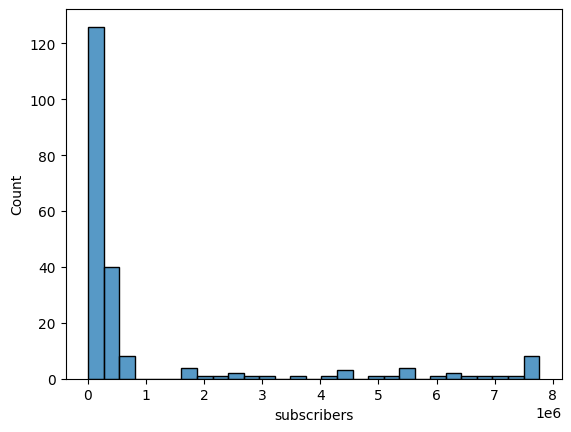

In [57]:
sns.histplot(df_videos, x="subscribers")

<Axes: xlabel='subscribers_minmax', ylabel='Count'>

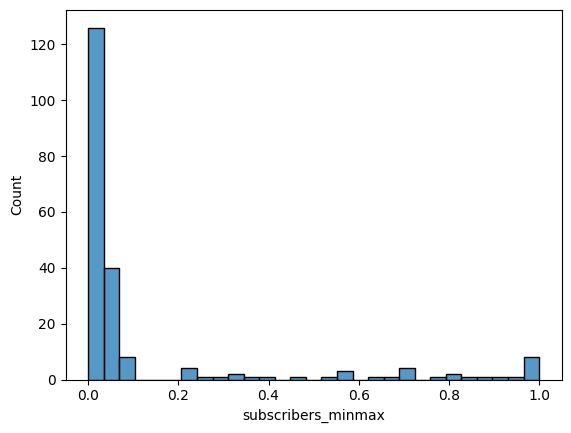

In [58]:
sns.histplot(df_videos, x="subscribers_minmax")

In [59]:
standard_scaler = StandardScaler()
df_videos["view_score"] = standard_scaler.fit_transform(df_videos[["views"]])
df_videos["view_score"].describe()

count    2.100000e+02
mean     2.537653e-17
std      1.002389e+00
min     -4.481625e-01
25%     -4.404694e-01
50%     -3.952794e-01
75%     -1.946757e-01
max      5.316044e+00
Name: view_score, dtype: float64

<Axes: xlabel='views', ylabel='Count'>

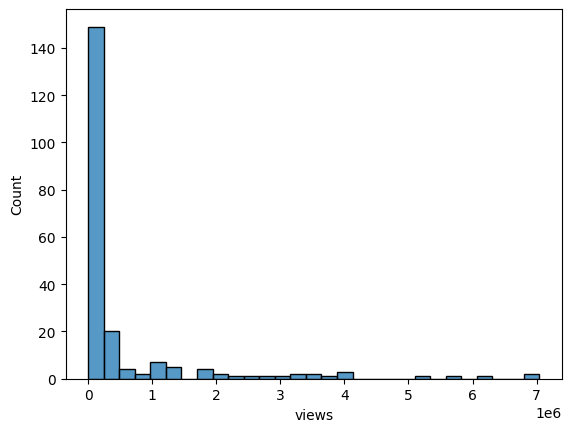

In [60]:
sns.histplot(df_videos, x="views")

<Axes: xlabel='views_scaled', ylabel='Count'>

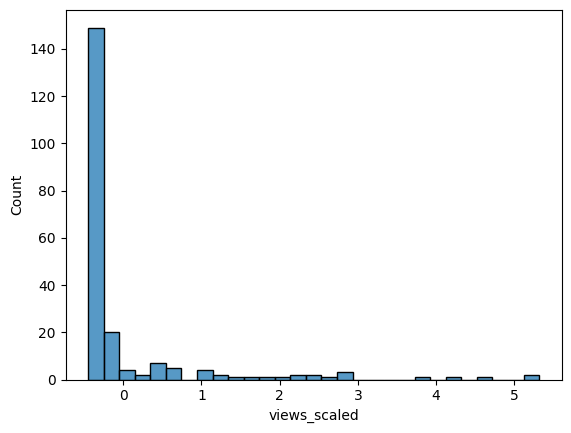

In [61]:
df_videos["views_scaled"] = standard_scaler.fit_transform(df_videos[["views"]])
sns.histplot(df_videos, x="views_scaled")

<Axes: xlabel='shares_scaled', ylabel='Count'>

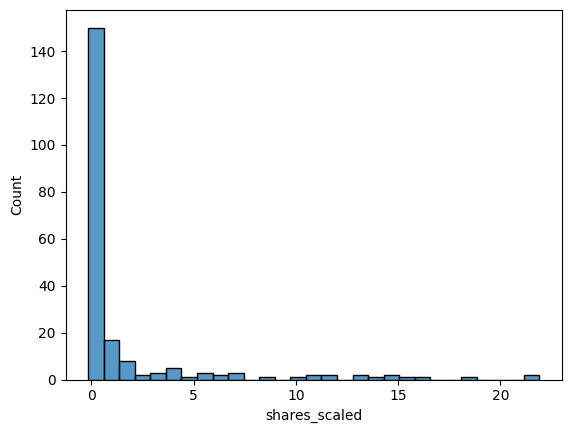

In [70]:
robust_scaler = RobustScaler()
df_videos["shares_scaled"] = robust_scaler.fit_transform(df_videos[["shares"]])
sns.histplot(df_videos, x="shares_scaled")

<Axes: xlabel='shares_scaled_standard', ylabel='Count'>

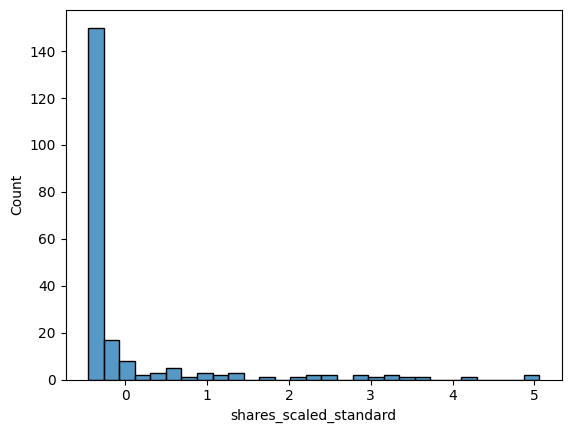

In [73]:
df_videos["shares_scaled_standard"] = standard_scaler.fit_transform(df_videos[["shares"]])
sns.histplot(df_videos, x="shares_scaled_standard")

<Axes: xlabel='likes_log', ylabel='Count'>

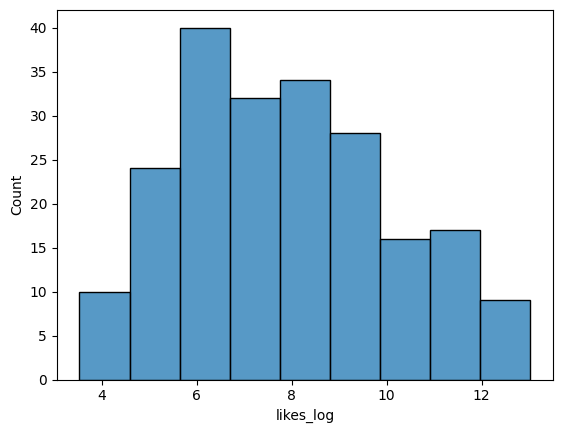

In [74]:
df_videos["likes_log"] = np.log1p(df_videos["likes"])
sns.histplot(df_videos, x="likes_log")

<Axes: xlabel='watch_time_minutes_bins', ylabel='count'>

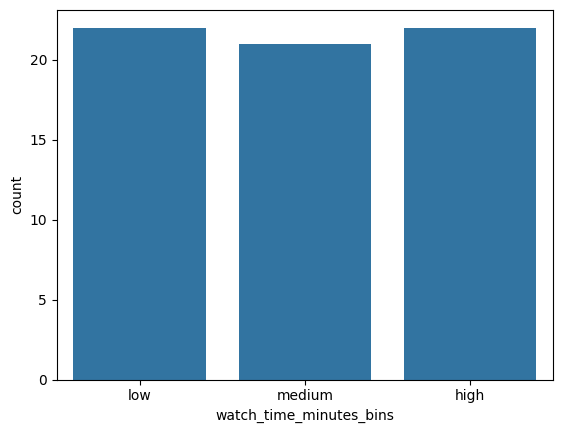

In [91]:
bins = [0, 50000, 100000, 200000]
labels = ["low", "medium", "high"]
df_videos["watch_time_minutes_bins"] = pd.cut(df_videos["watch_time_minutes"], bins=bins, labels=labels)
sns.countplot(df_videos, x="watch_time_minutes_bins")